# 03 — Evaluación del sistema GraphRAG (metodología RAGAS)

Este notebook evalúa el pipeline usando las tres métricas **RAGAS** descritas en
clase. El enfoque **no** requiere la librería RAGAS —
todas las métricas se implementan como llamadas estructuradas al LLM.

### Las tres métricas

| Métrica | Qué mide | Cómo |
|---|---|---|
| **context_recall** | ¿El recuperador obtuvo chunks que cubren la verdad esperada? | Cada frase del ground truth se verifica: ¿puede atribuirse al contexto recuperado? |
| **faithfulness** | ¿La respuesta contiene solo cosas respaldadas por el contexto? | La respuesta se descompone en afirmaciones atómicas; cada una se verifica contra el contexto. |
| **answer_correctness** | ¿Cuánto se superpone la respuesta con el ground truth? | Las afirmaciones se clasifican en TP / FP / FN; se calcula el F1. |

### El pipeline de evaluación

```
CSV de benchmark
  (question ; cypher)
	  │
	  ▼
  load_dataset()       ← lee el CSV, ejecuta Cypher para obtener ground truths dinámicos
	  │
	  ▼
  run_benchmark()      ← llama al agente RAG para cada pregunta, registra la latencia
	  │
	  ▼
  evaluate_results()   ← puntúa cada fila con las tres métricas RAGAS
	  │
	  ▼
  print_summary()      ← tabla agregada
```

**Requisito previo:** Ejecutar `01_ingestion_demo.ipynb` para cargar los datos de Einstein en Neo4j.

## 1. Configuración

In [11]:
import pandas as pd
from graph.neo4j_manager import Neo4jManager
from agents.multi_agent_system import MultiAgentSystem
from evaluation.evaluator import RAGEvaluator
import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 60)
pd.set_option('display.float_format', '{:.3f}'.format)


In [12]:
neo4j = Neo4jManager()
rag = MultiAgentSystem(neo4j, verbose=False)
evaluator = RAGEvaluator(rag, neo4j)
print("Sistema listo.")


Sistema listo.


## 2. Inspección de métricas — pregunta a pregunta

Antes de ejecutar el benchmark completo, es instructivo ver qué hace cada métrica
internamente. Tomamos una sola pregunta y llamamos a cada métrica de forma manual.

In [13]:
question     = "Give me a character who has the role of helper and then describe them."
ground_truth = """
{'ground_truth': "Character: monkey\nDescription: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.\n\nOR\n\nCharacter: pheasant\nDescription: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.\n\nOR\n\nCharacter: dog\nDescription: The dog is a companion of Momotaro. He breaks the bolts and bars with him.\n\nOR\n\nCharacter: crow\nDescription: A clever and resourceful bird who helps the bird catcher in his tasks and becomes a trusted advisor to the emperor."}
"""

# Preguntamos al agente
answer, context = evaluator.get_answer(question)
print(f"\nRespuesta: {answer}")
print(f"Chunks: {context}")
print(f"Chunks recuperados: {len(context)}")

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=2, column=9, offset=9>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 2, 'column': 9}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        CALL db.index.vector.queryNodes($index_name, $top_k, $query_embedding)\n        YIELD node, score\n\n        \nOPTIONAL MATCH (node)-[:HAS_ROLE]->(r:Role)\n\n\n        RETURN node.name AS name, node.description AS description, r.name AS role\n        ORDER BY score DESC\n        '



Respuesta: The characters with the role 'helper' are:

1. Monkey
   - Description: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.

2. Pheasant
   - Description: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.

3. Dog
   - Description: The dog is a companion of Momotaro. He breaks the bolts and bars with him.
Chunks: ['name: pheasant\ndescription: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.\nrole: helper']
Chunks recuperados: 1


In [14]:
# --- context_recall ---
# Objetivo: ¿puede atribuirse cada frase del ground truth al contexto recuperado?
# Puntuación = (frases atribuidas) / (total de frases)  →  rango [0, 1]
recall_result = evaluator.evaluate_context_recall(question, ground_truth, context, verbose=True)

print("context_recall")
print(f"  puntuación : {recall_result.recall:.3f}")
print(f"  frases     : {recall_result.sentences}")
print(f"  atribuidas : {recall_result.attributions}")
print(f"  razonamiento: {recall_result.reasoning}")


── context_recall ──────────────────────────────────
  Question    : Give me a character who has the role of helper and then describe them.
  Ground truth: 
{'ground_truth': "Character: monkey
Description: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.

OR

Character: pheasant
Description: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.

OR

Character: dog
Description: The dog is a companion of Momotaro. He breaks the bolts and bars with him.

OR

Character: crow
Description: A clever and resourceful bird who helps the bird catcher in his tasks and becomes a trusted advisor to the emperor."}

  Context chunks retrieved: 1

  [Step 1] Asking the LLM to attribute each ground-truth sentence to context...

  Ground-truth sentences (1):
    [✓ attributed] The pheasant is a helper character, as described in the context. The description of the pheasant matches the ground truth answer.

  Reasoning : The ground truth ans

In [15]:
# --- faithfulness ---
# Paso 1: descomponer la respuesta en afirmaciones atómicas sin pronombres.
# Paso 2: verificar si cada afirmación puede inferirse del contexto.
# Puntuación = (afirmaciones respaldadas) / (total)  →  rango [0, 1]
faith_result = evaluator.evaluate_faithfulness(question, str(answer), context, verbose=True)

print("faithfulness")
print(f"  puntuación  : {faith_result.faithfulness:.3f}")
print(f"  afirmaciones: {faith_result.statements}")
print(f"  veredictos  : {faith_result.verdicts}")


── faithfulness ────────────────────────────────────
  Question: Give me a character who has the role of helper and then describe them.
  Answer  : The characters with the role 'helper' are:

1. Monkey
   - Description: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.

2. Pheasant
   - Description: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.

3. Dog
   - Description: The dog is a companion of Momotaro. He breaks the bolts and bars with him.

  [Step 1] Decomposing the answer into statements...
  Statements extracted (6):
    1. Monkey is a helper.
    2. The monkey accompanies Momotaro to Ogres' Island.
    3. Pheasant is a helper.
    4. The pheasant flies over the castle gate to peck the Ogres.
    5. Dog is a helper.
    6. The dog breaks bolts and bars with Momotaro.

  [Step 2] Context detected.
           Using retrieval-grounded mode...

  Verdicts:
    [✓ supported] Monkey is a helper.
              → T

In [16]:
# --- answer_correctness ---
# Se descomponen tanto la respuesta como el ground truth en afirmaciones.
# Cada afirmación se clasifica en TP / FP / FN.
# Puntuación = F1(precisión, recall) calculado a partir de los conteos TP / FP / FN.
corr_result = evaluator.evaluate_answer_correctness(question, str(answer), ground_truth, verbose=True)

print("answer_correctness")
print(f"  F1        : {corr_result.answer_correctness:.3f}")
print(f"  precisión : {corr_result.precision:.3f}")
print(f"  recall    : {corr_result.recall:.3f}")
print(f"  TP={corr_result.tp}  FP={corr_result.fp}  FN={corr_result.fn}")



── answer_correctness ──────────────────────────────
  Question    : Give me a character who has the role of helper and then describe them.
  Answer      : The characters with the role 'helper' are:

1. Monkey
   - Description: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.

2. Pheasant
   - Description: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.

3. Dog
   - Description: The dog is a companion of Momotaro. He breaks the bolts and bars with him.
  Ground truth: 
{'ground_truth': "Character: monkey
Description: The monkey is a companion of Momotaro. He goes to the Ogres' Island with him.

OR

Character: pheasant
Description: The pheasant is a companion of Momotaro. He flies over the castle gate to peck the Ogres.

OR

Character: dog
Description: The dog is a companion of Momotaro. He breaks the bolts and bars with him.

OR

Character: crow
Description: A clever and resourceful bird who helps the bird catcher 

## 3. Pipeline de benchmark completo

### Formato del dataset de benchmark

El benchmark es un CSV delimitado por punto y coma con dos columnas:
- `question` — la pregunta en lenguaje natural
- `cypher` — una consulta Cypher que se **ejecuta en tiempo de ejecución** para obtener el ground truth

Este diseño garantiza que los ground truths estén siempre sincronizados con el estado
real del grafo: no hay cadenas de texto codificadas que queden desactualizadas al cambiar los datos.

### Categorías de preguntas

| Categoría | Ejemplos | Propósito |
|---|---|---|
| **Saludos** | "Hello", "What can you do?" | Evaluar respuesta conversacional |
| **Fuera de ámbito** | "Weather?", "World Cup?" | Evaluar rechazo correcto |
| **Datos ausentes** | "Einstein's middle name?" | Evaluar honestidad del sistema |
| **Hechos simples** | "Where was Einstein born?" | Evaluar recuperación directa |
| **Consultas relacionales** | "Which institutions did Einstein work at?" | Evaluar traversal de grafo |
| **Consultas complejas** | "Where did Einstein live after Germany?" | Evaluar razonamiento multi-salto |
| **Agregaciones** | "How many Person nodes?" | Evaluar text2cypher |


In [17]:
dataset = evaluator.load_dataset('./data/benchmark_data.csv')
print(f"Benchmark CSV: {len(dataset)} preguntas")
dataset.head()


Benchmark CSV: 36 preguntas


,question,cypher,type
0,Hello,"RETURN ""Hello! I'm a knowledge assistant focused on folk...",greeting
1,What can you do?,"RETURN ""I can answer questions about folktales: their na...",greeting
2,How is the weather today?,"RETURN ""This question is outside my scope."" AS ground_truth",out_of_scope
3,Who won the last football World Cup?,"RETURN ""This question is outside my scope."" AS ground_truth",out_of_scope
4,What is the capital of France?,RETURN 'This question is outside my scope.' AS ground_truth,out_of_scope


In [18]:
for i, row in dataset.iterrows():
	question = row["question"]
	cypher = row["cypher"]
	
	result = neo4j.execute_query(cypher)
	print(f"{question}: {result}")


Hello: [{'ground_truth': "Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured."}]
What can you do?: [{'ground_truth': 'I can answer questions about folktales: their narrative structure, the characters that make them up and their features, the relevant places and objects that appear, among others.'}]
How is the weather today?: [{'ground_truth': 'This question is outside my scope.'}]
Who won the last football World Cup?: [{'ground_truth': 'This question is outside my scope.'}]
What is the capital of France?: [{'ground_truth': 'This question is outside my scope.'}]
Which movies did Momotaro appear in?: [{'ground_truth': 'This question is outside my scope.'}]
What is Momotaro's surname?: [{'ground_truth': 'This information is not in the knowledge base.'}]
Hold old is Momotaro?: [{'ground_truth': 'This information is not in the knowledge base.'}]
What is the town population i

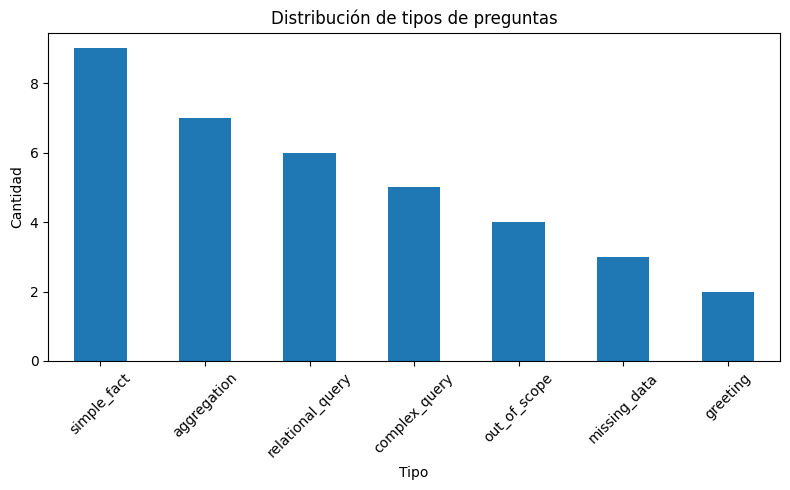

In [19]:
counts = dataset["type"].value_counts()

plt.figure(figsize=(8,5))
counts.plot(kind="bar")
plt.title("Distribución de tipos de preguntas")
plt.xlabel("Tipo")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### 3.1 `run_benchmark()` — ejecutar ground truths Cypher y llamar al agente

Para cada fila:
1. Ejecuta la consulta Cypher → string con el ground truth
2. Llama a `rag.answer(question)` → respuesta del agente + contextos recuperados
3. Registra la latencia en segundos

In [ ]:
results_df = evaluator.run_benchmark(dataset, verbose=True)

print(f"\nBenchmark completo — {len(results_df)} filas")
results_df[['question', 'ground_truth', 'answer', 'latency']]

Processing rows:   0%|          | 0/36 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [1/36] Hello
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN "Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured." AS ground_truth
  Ground truth: Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured.

  [Step 2] Calling the RAG agent...


Processing rows:   3%|▎         | 1/36 [00:06<04:01,  6.91s/it]

  Answer  : Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured.
  Context chunks: 0
  Latency : 6.90s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [2/36] What can you do?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           RETURN "I can answer questions about folktales: their narrative structure, the characters that make them up and their features, the relevant places and objects that appear, among others." AS ground_truth
  Ground truth: I can answer questions about folktales: their narrative structure, the characters that make them up and their features, the relevant places and objects that appear, among others.

  [Step 2] Calling the RAG agent...


Processing rows:   6%|▌         | 2/36 [00:09<02:34,  4.53s/it]

...

  Answer  : The tiger character's personality traits are:
- Openness: 0.4
- Conscientiousness: 0.6
- Extraversion: 0.8
- Agreeableness: 0.2
- Neuroticism: 0.1
  Context chunks: 10
  Latency : 105.57s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [32/36] Give me the first 3 events of 'How the Tiger Got Its Stripes.'
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           MATCH (f:Folktale {title: "How the Tiger Got His Stripes"})-[:HAS_EVENT]->(e:Event) RETURN e.name AS ground_truth ORDER BY e.order ASC LIMIT 3
  Ground truth: Tiger Seeks Farm Worker; Tiger Offers Work Reward; Tiger Rejects Monkey Worker

  [Step 2] Calling the RAG agent...


Processing rows:  89%|████████▉ | 32/36 [20:53<04:22, 65.71s/it]

  Answer  : This information is not in the knowledge base.
  Context chunks: 0
  Latency : 48.00s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [33/36] What happened to Momotaro and his companions when they were in The Ogres' Island castle?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           MATCH (p:Place)<-[:TAKES_PLACE_IN]-(e:Event) WHERE toLower(p.name) CONTAINS "ogres' island castle" RETURN e.description AS ground_truth ORDER BY e.order
  Ground truth: But the old man never got a taste of the peach. And why did he not?All of a sudden the peach burst in two and there was no stone to it, but a fine boy baby where the stone should have been.“Mercy me!” says the old woman.“Mercy me!” says the old man.; “Why,” says Momotaro, “I’m going on a journey, or as you may say, an adventure, and I shall be needing the kimi-dango on the way.”“Where are you going, Momotaro?” says his mother.“I’m off to the Ogres’ Isl

Received notification from DBMS server: <GqlStatusObject gql_status='01N01', status_description='warn: feature deprecated with replacement. db.index.vector.queryNodes is deprecated. It is replaced by SEARCH.', position=<SummaryInputPosition line=4, column=13, offset=60>, raw_classification='DEPRECATION', classification=<NotificationClassification.DEPRECATION: 'DEPRECATION'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'DEPRECATION', '_severity': 'WARNING', '_position': {'offset': 60, 'line': 4, 'column': 13}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: '\n        CALL () {\n            // Vector search\n            CALL db.index.vector.queryNodes($vector_index, $top_k, $query_embedding)\n            YIELD node, score\n            \n            WITH collect({node: node, score: score}) AS nodes, max(score) AS maxScore, min(score) AS minScore\n            UNWIND nodes AS n\n            RET

  Answer  : Momotaro and his companions overcame the Ogre resistance when they were in The Ogres' Island castle.
  Context chunks: 1
  Latency : 58.27s

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [34/36] What happened after the tailor was put in prison?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  [Step 1] Executing Cypher ground truth...
           MATCH (f:Folktale)-[:HAS_EVENT]->(e1:Event)-[:POST_EVENT]->(e2:Event) WHERE toLower(e1.description) CONTAINS "prison" AND toLower(e1.description) CONTAINS "tailor" RETURN e2.description AS ground_truth LIMIT 1
  Ground truth: All went on well for a time, but then tailor fell into his old ways, and was surly and quarrelsome. And because tailor dared not beat her, he would seize her by the hair and tear it out. The woman escaped from him, and sprang out into the yard, but he ran after her with his yard-measure and scissors, and chased her about, and threw the yard-measure and scissors at her, and whatever

### 3.2 `evaluate_results()` — puntuar cada fila con las tres métricas RAGAS

Este paso es el más intensivo en LLM: cada fila hace ~5 llamadas al LLM
(context_recall × 1, faithfulness × 2, answer_correctness × 3).
Esperar unos 10–30 segundos por fila dependiendo del modelo.

In [ ]:
scored_df = evaluator.evaluate_results(results_df, verbose=True)

print(f"\nPuntuación completada.")
scored_df[['question', 'context_recall', 'faithfulness', 'answer_correctness', 'latency']]

Evaluating:   0%|          | 0/35 [00:00<?, ?it/s]


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Hello
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : Hello
  Ground truth: Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured.
  Context chunks retrieved: 0

  [Step 1] No retrieved context detected.
    [✓ attributed] Hello! I'm a knowledge assistant focused on folktales from all around the world. You can ask me about their characters, relationships, themes or how they are structured.

  Reasoning : No context was retrieved, and the ground truth is a conversational, scope-refusal, or KB-abstention response that requires no knowledge lookup. Recall = 1.0.
  Score     : 1.000
────────────────────────────────────────────────────

── faithfulness ────────────────────────────────────
  Question: Hello
  Answer  : Hello! I'm a

Evaluating:   3%|▎         | 1/35 [01:20<45:43, 80.69s/it]

  Classifications:
    [TP] The text is a greeting. — Equivalent to ground truth statement 1.
    [TP] A knowledge assistant is being described. — Equivalent to ground truth statement 2.
    [TP] The assistant's focus is on folktales from various locations worldwide. — Equivalent to ground truth statement 3.
    [TP] The assistant can provide information about the characters in these folktales. — Equivalent to ground truth statement 4.
    [TP] The assistant can also provide information about the relationships between characters in these folktales. — Equivalent to ground truth statement 5.
    [FP] The assistant can provide information about the themes present in these folktales. — Minor stylistic addition, but introduces no new factual content.
    [FN] The assistant can provide information about how these folktales are structured. — Important statement missing from the answer.

  TP=6  FP=1  FN=1
  Precision=0.857  Recall=0.857  F1=0.857
──────────────────────────────────────────────

Evaluating:   6%|▌         | 2/35 [02:40<44:07, 80.21s/it]

...

Evaluating:  97%|█████████▋| 34/35 [22:59<00:42, 42.84s/it]

  Classifications:
    [FN] The answer does not contain information about what happened to the tailor. — Ground truth statement 1 mentions that the tailor was in prison for a time, which is missing from the answer.
    [TP] There is no information available about the events that occurred after the tailor was imprisoned. — This statement is equivalent to ground truth statements 2-4, as it implies that there are no significant changes in the tailor's behavior after imprisonment.

  TP=1  FP=0  FN=1
  Precision=1.000  Recall=0.500  F1=0.667
────────────────────────────────────────────────────

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Q: Which are the 3 most important characters based on the number of events they appear in?
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

── context_recall ──────────────────────────────────
  Question    : Which are the 3 most important characters based on the number of events they appear in?
  Ground truth: rabbit; tiger

Evaluating: 100%|██████████| 35/35 [23:22<00:00, 40.07s/it]

  Classifications:
    [FN] The text does not provide information about the three most important characters. — Ground truth only mentions specific characters, but answer statement is too broad.
    [TP] There is no data available to determine which characters are the most important. — Equivalent restatement of ground truth statements 1-3.

  TP=1  FP=0  FN=1
  Precision=1.000  Recall=0.500  F1=0.667
────────────────────────────────────────────────────

Puntuación completada.


,question,context_recall,faithfulness,answer_correctness,latency
0,Hello,1.000,2.500,0.857,6.817
1,What can you do?,1.000,3.500,0.833,2.474
2,What is the weather like today?,1.000,0.000,0.667,2.100
3,Who won the last football World Cup?,1.000,0.000,0.667,2.319
4,What is the capital of France?,1.000,0.500,1.000,3.358
5,Which movies did Momotaro appear in?,1.000,1.000,0.667,21.292
6,What is Momotaro's surname?,0.000,1.000,0.667,50.313
7,Hold old is Momotaro?,1.000,1.000,1.000,24.688
8,What is the town population in 'Sharing Joy and Sorrow'?,1.000,1.000,1.000,19.650
9,List all Genre nodes in the graph,1.000,1.000,0.667,25.320


### 3.3 `print_summary()` — resultados agregados

El resumen reproduce la tabla de resumen de benchmark que hemos comentado en clase.
Un sistema bien ajustado debería superar 0.7 en las tres métricas.

In [ ]:
evaluator.print_summary(scored_df)


=== Benchmark Summary ===
answer_correctness       : 0.6999
context_recall           : 0.6571
faithfulness             : 0.9733
avg_latency_s            : 47.46


## 4. Análisis de resultados

### 4.1 Distribución por métrica

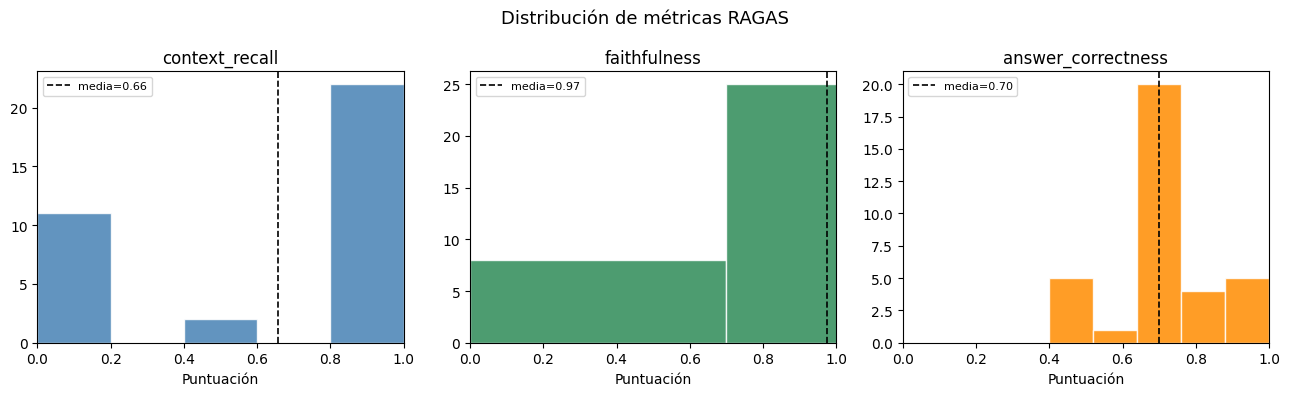

In [ ]:
metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Distribución de métricas RAGAS', fontsize=13)

for ax, metric, color in zip(axes, metrics, colors):
	ax.hist(scored_df[metric].dropna(), bins=5, color=color, edgecolor='white', alpha=0.85)
	ax.axvline(scored_df[metric].mean(), color='black', linestyle='--', linewidth=1.2,
			   label=f'media={scored_df[metric].mean():.2f}')
	ax.set_title(metric)
	ax.set_xlabel('Puntuación')
	ax.set_xlim(0, 1)
	ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

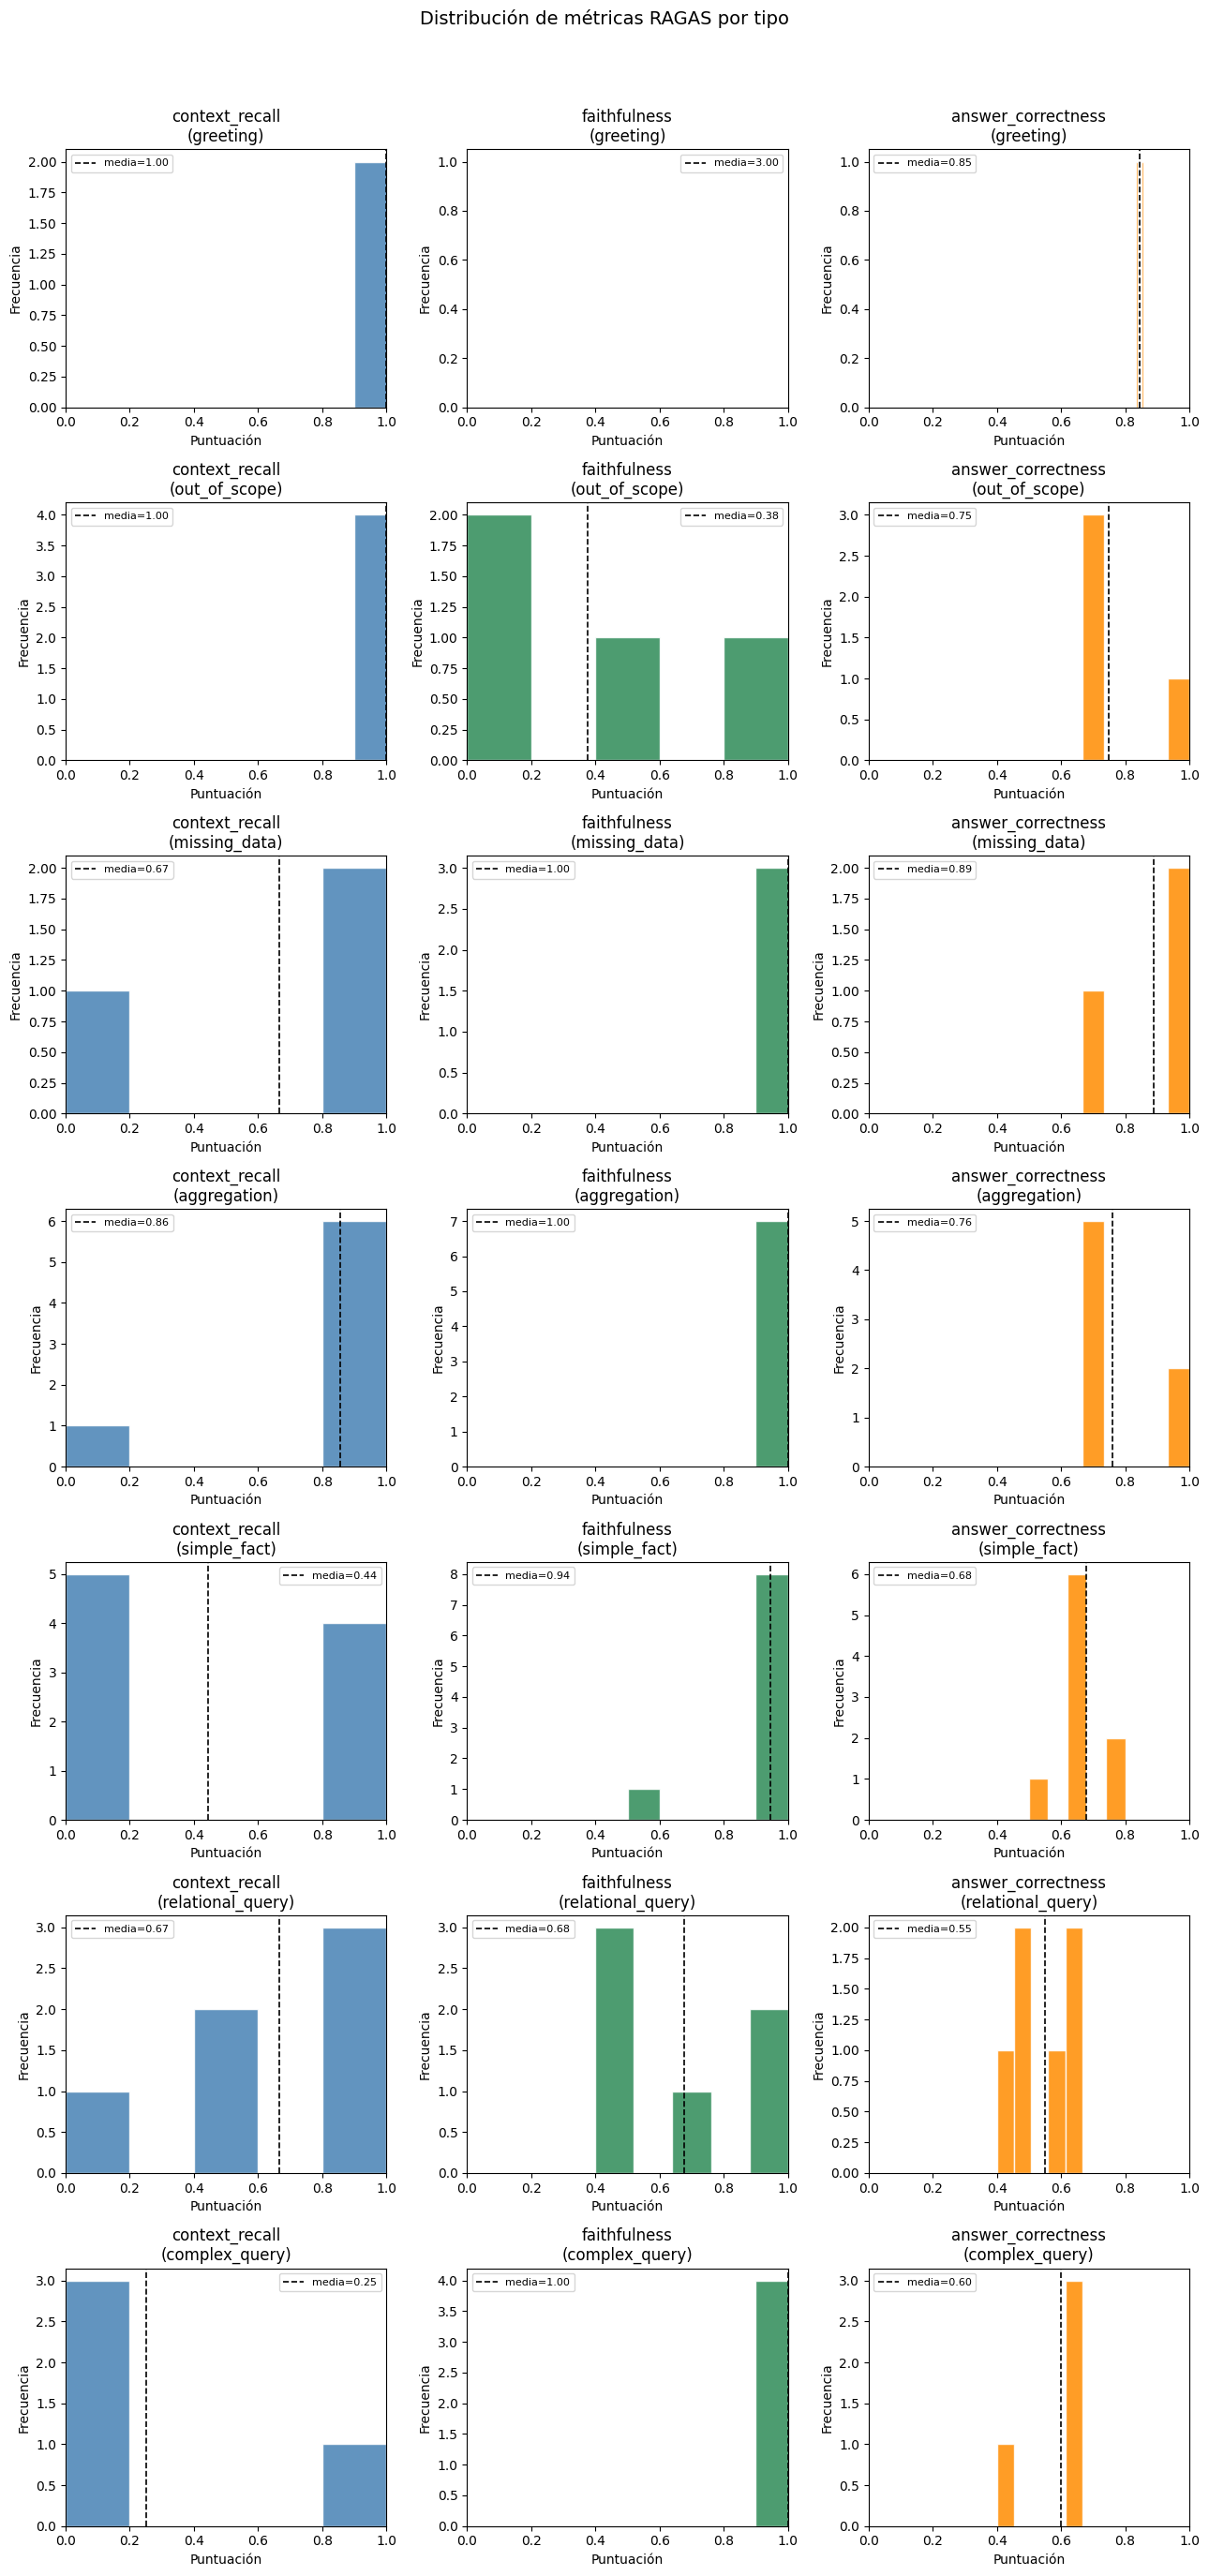

In [ ]:
metrics = ['context_recall', 'faithfulness', 'answer_correctness']
colors  = ['steelblue', 'seagreen', 'darkorange']

types = scored_df["type"].dropna().unique()

fig, axes = plt.subplots(len(types), 3, figsize=(13, 4 * len(types)))
fig.suptitle('Distribución de métricas RAGAS por tipo', fontsize=14)

if len(types) == 1:
    axes = [axes]

for row, qtype in enumerate(types):

    subset = scored_df[scored_df["type"] == qtype]

    for col, (metric, color) in enumerate(zip(metrics, colors)):

        ax = axes[row][col]

        ax.hist(
            subset[metric].dropna(),
            bins=5,
            color=color,
            edgecolor='white',
            alpha=0.85
        )

        mean_val = subset[metric].mean()

        ax.axvline(
            mean_val,
            color='black',
            linestyle='--',
            linewidth=1.2,
            label=f'media={mean_val:.2f}'
        )

        ax.set_title(f'{metric}\n({qtype})')
        ax.set_xlabel('Puntuación')
        ax.set_ylabel('Frecuencia')
        ax.set_xlim(0, 1)
        ax.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


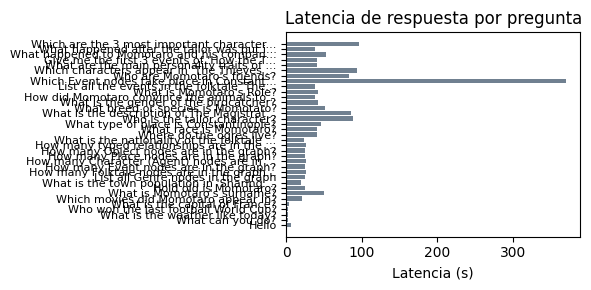

In [ ]:
# Distribución de latencia
fig, ax = plt.subplots(figsize=(6, 3))
ax.barh(range(len(scored_df)), scored_df['latency'], color='slategray')
ax.set_yticks(range(len(scored_df)))
ax.set_yticklabels(
	[q[:40] + '...' if len(q) > 40 else q for q in scored_df['question']],
	fontsize=8
)
ax.set_xlabel('Latencia (s)')
ax.set_title('Latencia de respuesta por pregunta')
plt.tight_layout()
plt.show()

### 4.2 Mejor y peor caso por answer_correctness

Inspeccionar los extremos ayuda a diagnosticar *por qué* falla el sistema:
- `context_recall` bajo → el recuperador no encontró los chunks relevantes → ajustar `chunk_size` o `top_k`
- `faithfulness` bajo → el LLM alucinó → mejorar el prompt de respuesta o añadir instrucciones de anclaje
- `answer_correctness` bajo con `faithfulness` alto → el contexto recuperado era incompleto

In [ ]:
def show_case(label, row):
	print(f"{'='*70}")
	print(label)
	print(f"{'='*70}")
	print(f"Question        : {row['question']}")
	print(f"Ground truth    : {str(row['ground_truth'])[:200]}")
	print(f"Answer          : {str(row['answer'])[:200]}")
	print(f"answer_correctness : {row['answer_correctness']:.3f}")
	print(f"context_recall     : {row['context_recall']:.3f}")
	print(f"faithfulness       : {row['faithfulness']:.3f}")
	print()

best_idx  = scored_df['answer_correctness'].idxmax()
worst_idx = scored_df['answer_correctness'].idxmin()

show_case("MEJOR CASO",  scored_df.loc[best_idx])
show_case("PEOR CASO", scored_df.loc[worst_idx])

MEJOR CASO
Question        : What is the capital of France?
Ground truth    : This question is outside my scope.
Answer          : This question is outside my scope.
answer_correctness : 1.000
context_recall     : 1.000
faithfulness       : 0.500

PEOR CASO
Question        : What are the main personality traits of the tiger character?
Ground truth    : extraversion (0.8); conscientiousness (0.6); conscientiousness (0.6); neuroticism (0.5); neuroticism (0.5)
Answer          : This information is not in the knowledge base.
answer_correctness : 0.400
context_recall     : 0.000
faithfulness       : 1.000



### 4.3 Correlación entre métricas

¿Son las tres métricas independientes o tienden a moverse juntas?
Una correlación fuerte entre `context_recall` y `answer_correctness` confirmaría
que la calidad de la recuperación es el principal cuello de botella.

In [ ]:
corr = scored_df[metrics].corr()
print("Correlación de Pearson entre métricas:")
print(corr.round(3))

Correlación de Pearson entre métricas:
                    context_recall  faithfulness  answer_correctness
context_recall               1.000         0.078               0.312
faithfulness                 0.078         1.000               0.241
answer_correctness           0.312         0.241               1.000


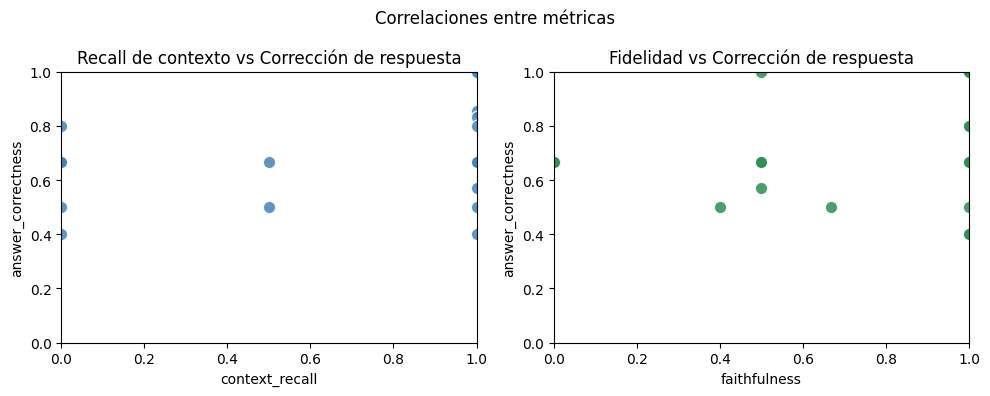

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(scored_df['context_recall'], scored_df['answer_correctness'],
				color='steelblue', edgecolors='white', s=80, alpha=0.85)
axes[0].set_xlabel('context_recall')
axes[0].set_ylabel('answer_correctness')
axes[0].set_title('Recall de contexto vs Corrección de respuesta')
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

axes[1].scatter(scored_df['faithfulness'], scored_df['answer_correctness'],
				color='seagreen', edgecolors='white', s=80, alpha=0.85)
axes[1].set_xlabel('faithfulness')
axes[1].set_ylabel('answer_correctness')
axes[1].set_title('Fidelidad vs Corrección de respuesta')
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Correlaciones entre métricas', fontsize=12)
plt.tight_layout()
plt.show()

## 5. Guardar resultados

In [ ]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
out_path = f"./data/evaluation_results_{timestamp}.csv"
scored_df.to_csv(out_path, index=False)
print(f"Resultados guardados en {out_path}")


Resultados guardados en ./data/evaluation_results_20260512_101915.csv


In [19]:
neo4j.close()
